<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/07-fraud-detection/fraud_detection_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# [Cell 1] Kaggle API 연결 (kaggle.json 파일 없이 직접 설정)
# ============================================================
!pip install --quiet kaggle

import os
from getpass import getpass

# ------------------------------------------------------------
# username과 API 키를 화면에 노출되지 않게 입력받아 환경변수로 등록
# ------------------------------------------------------------
os.environ['KAGGLE_USERNAME'] = input("Kaggle 사용자명(username)을 입력하세요: ")
os.environ['KAGGLE_KEY'] = getpass("Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ")

# ------------------------------------------------------------
# Credit Card Fraud Detection 데이터셋 다운로드
# ------------------------------------------------------------
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

import pandas as pd
df = pd.read_csv('creditcard.csv')
print(f"데이터 크기: {df.shape}")
print(f"\n사기거래(Class=1) 비율: {df['Class'].mean()*100:.4f}%")
print(f"사기거래 건수: {df['Class'].sum()}건 / 전체: {len(df):,}건")
print(df.head())

Kaggle 사용자명(username)을 입력하세요: KIMDAEYU
Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ··········
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 117MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          
데이터 크기: (284807, 31)

사기거래(Class=1) 비율: 0.1727%
사기거래 건수: 492건 / 전체: 284,807건
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.

284,807건 중 사기거래 492건(0.1727%)

데이터 구조 참고: V1~V28은 원래 거래정보(가맹점, 위치 등 민감정보)를 PCA로 익명화한 값들이라 개별 의미는 알 수 없지만, Time(첫 거래 이후 경과초), Amount(거래금액), Class(사기여부, 1=사기)는 원본 그대로이다.

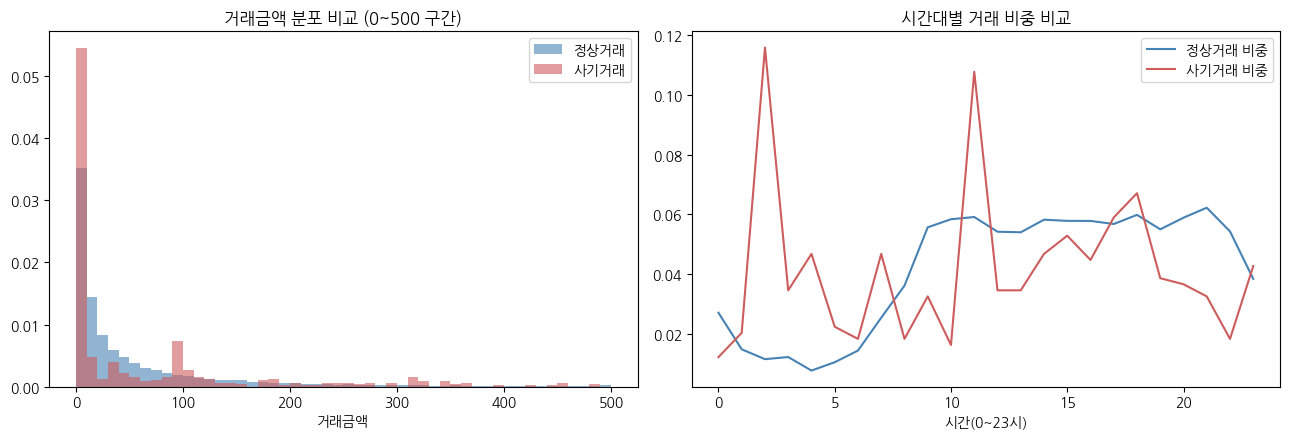

=== 정상거래 vs 사기거래 금액 통계 ===
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [2]:
# ============================================================
# [Cell 2] 데이터 탐색 + 전처리 (스케일링)
# ============================================================
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

!apt-get -qq install fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------
# 1) Amount, Time 스케일링
# ------------------------------------------------------------
# V1~V28은 이미 PCA로 표준화되어 있지만, Amount와 Time은
# 원본 단위(원, 초)라 스케일이 다른 변수들과 안 맞음 -> 표준화 필요
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# ------------------------------------------------------------
# 2) 정상거래 vs 사기거래의 거래금액 분포 비교
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, color='steelblue',
             label='정상거래', density=True, range=(0, 500))
axes[0].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, color='indianred',
             label='사기거래', density=True, range=(0, 500))
axes[0].set_title('거래금액 분포 비교 (0~500 구간)')
axes[0].set_xlabel('거래금액')
axes[0].legend()

# ------------------------------------------------------------
# 3) 시간대별 사기거래 발생 패턴 (Time을 24시간 단위로 환산)
# ------------------------------------------------------------
df['hour'] = (df['Time'] // 3600) % 24
fraud_by_hour = df[df['Class']==1].groupby('hour').size()
normal_by_hour_ratio = df[df['Class']==0].groupby('hour').size() / len(df[df['Class']==0])
fraud_by_hour_ratio = fraud_by_hour / len(df[df['Class']==1])

axes[1].plot(normal_by_hour_ratio.index, normal_by_hour_ratio.values, label='정상거래 비중', color='steelblue')
axes[1].plot(fraud_by_hour_ratio.index, fraud_by_hour_ratio.values, label='사기거래 비중', color='indianred')
axes[1].set_title('시간대별 거래 비중 비교')
axes[1].set_xlabel('시간(0~23시)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) 요약 통계 비교
# ------------------------------------------------------------
print("=== 정상거래 vs 사기거래 금액 통계 ===")
print(df.groupby('Class')['Amount'].describe())

확인 포인트

왼쪽 그래프: 사기거래(빨강)가 정상거래(파랑)보다 소액 구간에 더 몰려있는지 (카드사기는 의심을 피하려 소액을 여러 번 시도하는 경향이 실제로 있다.)
오른쪽 그래프: 사기거래 비중이 특정 시간대(주로 새벽)에 튀는 패턴이 있는지 — 이게 있으면 나중에 모델에 시간대 정보를 활용할 근거가 된다.

왼쪽(금액 분포): 사기거래(빨강)가 0 근처와 90 ~ 100 구간에 뾰족하게 몰려있다. 0 근처 몰림은 소액으로 카드가 살아있는지 테스트하는 전형적 사기 패턴, 90~100 구간의 스파이크는 특정 금액대(아마 한도 직전 또는 특정 가맹점 표준 결제액)를 노린 패턴일 가능성이 높다.

오른쪽(시간대): 새벽 2시, 11시경에 사기거래 비중이 정상거래 대비 훨씬 튀어 오르는 게 뚜렷하다. 특히 새벽 시간대는 카드 소유자가 잠들어 있어 이상거래 알림에 반응이 늦어지는 시간이라 사기범들이 선호하는 시간대라는 실무 지식과도 맞아떨어진다.

이 두 발견은 나중에 Isolation Forest가 실제로 유의미한 이상치를 잡아내는지 검증할 때 참고할 만한 "직관적 기준점"이 된다.

=== Isolation Forest 성능 ===
PR-AUC(Average Precision): 0.1635
ROC-AUC: 0.9474

혼동행렬:
        예측:정상  예측:사기
실제:정상  283883    432
실제:사기     354    138

분류 리포트:
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00    284315
          사기       0.24      0.28      0.26       492

    accuracy                           1.00    284807
   macro avg       0.62      0.64      0.63    284807
weighted avg       1.00      1.00      1.00    284807



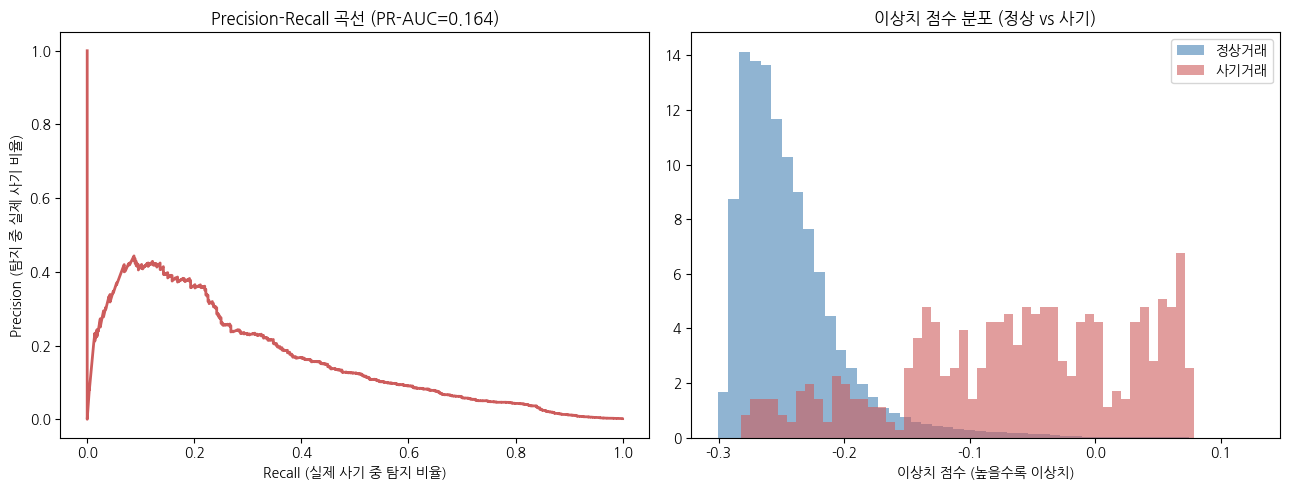

In [3]:
# ============================================================
# [Cell 3] Isolation Forest 학습 + 평가
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                               confusion_matrix, classification_report, roc_auc_score)

# ------------------------------------------------------------
# 1) 학습용 피처 구성 (V1~V28 + 스케일링된 Amount, Time)
# ------------------------------------------------------------
feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y_true = df['Class']

# ------------------------------------------------------------
# 2) Isolation Forest 학습
# ------------------------------------------------------------
# contamination: 데이터 내 이상치(사기) 비율을 모델에 미리 알려주는 파라미터
# 실제 사기 비율(0.1727%)과 비슷하게 설정 -> 실무에서는 이 값을 모르는 경우가
# 많아 약간 여유를 두고 설정하는 게 일반적 (여기선 0.002로 설정)
iso_forest = IsolationForest(
    n_estimators=200,      # 나무 개수 (많을수록 안정적, 대신 느려짐)
    contamination=0.002,
    max_samples='auto',
    random_state=42,
    n_jobs=-1               # 가용 CPU 코어 모두 사용해서 속도 향상
)
iso_forest.fit(X)

# ------------------------------------------------------------
# 3) 이상치 점수 산출
# ------------------------------------------------------------
# decision_function: 값이 낮을수록(음수에 가까울수록) 더 이상치에 가까움
# 부호를 뒤집어서 "높을수록 사기 위험 높음"으로 직관적으로 바꿔줌
anomaly_score = -iso_forest.decision_function(X)
y_pred = (iso_forest.predict(X) == -1).astype(int)  # -1=이상치(사기 예측), 1=정상

# ------------------------------------------------------------
# 4) 평가: 불균형 데이터에 적합한 지표 (Precision-Recall AUC 중심)
# ------------------------------------------------------------
pr_auc = average_precision_score(y_true, anomaly_score)
roc_auc = roc_auc_score(y_true, anomaly_score)

print(f"=== Isolation Forest 성능 ===")
print(f"PR-AUC(Average Precision): {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"\n혼동행렬:")
cm = confusion_matrix(y_true, y_pred)
print(pd.DataFrame(cm, index=['실제:정상', '실제:사기'], columns=['예측:정상', '예측:사기']))
print(f"\n분류 리포트:")
print(classification_report(y_true, y_pred, target_names=['정상', '사기']))

# ------------------------------------------------------------
# 5) 시각화: Precision-Recall 곡선 + 이상치 점수 분포
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

precision, recall, _ = precision_recall_curve(y_true, anomaly_score)
axes[0].plot(recall, precision, color='indianred', lw=2)
axes[0].set_xlabel('Recall (실제 사기 중 탐지 비율)')
axes[0].set_ylabel('Precision (탐지 중 실제 사기 비율)')
axes[0].set_title(f'Precision-Recall 곡선 (PR-AUC={pr_auc:.3f})')

axes[1].hist(anomaly_score[y_true==0], bins=50, alpha=0.6, color='steelblue',
             label='정상거래', density=True)
axes[1].hist(anomaly_score[y_true==1], bins=50, alpha=0.6, color='indianred',
             label='사기거래', density=True)
axes[1].set_title('이상치 점수 분포 (정상 vs 사기)')
axes[1].set_xlabel('이상치 점수 (높을수록 이상치)')
axes[1].legend()

plt.tight_layout()
plt.show()

Isolation Forest 모델 학습 + 평가

중요한 개념: Isolation Forest는 비지도학습이다. 즉 Class(정답 라벨)를 학습에 전혀 쓰지 않고, "다른 거래들과 패턴이 확연히 다른 거래"를 자동으로 찾아낸다. 라벨은 오직 "이 모델이 실제로 사기를 잘 찾아내는지" 사후 검증에만 사용한다. — 이게 실무에서 중요한 이유는, 신종 사기수법처럼 한 번도 라벨링된 적 없는 새로운 패턴도 탐지할 수 있는 가능성이 있기 때문이다.

확인 포인트 : 이런 극심한 불균형 데이터에서는 일반 정확도(accuracy)가 아니라 PR-AUC를 핵심 지표로 봐야 한다. 랜덤 예측 시 PR-AUC는 이론상 0.0017(사기 비율)에 가깝기 때문에, 0.2~0.4 정도만 나와도 랜덤보다 훨씬 유의미한 수준이다.
오른쪽 히스토그램에서 빨간색(사기)이 파란색(정상)보다 오른쪽(높은 이상치 점수)에 더 몰려있으면, 라벨을 전혀 안 썼는데도 모델이 방향성을 제대로 잡았다는 뜻이라 이게 이 프로젝트의 핵심 증명 포인트이다.

1) ROC-AUC 0.9474 vs PR-AUC 0.1635 — 왜 이렇게 차이가 클까?
이게 이번 프로젝트에서 가장 중요한 개념이다. ROC-AUC는 0.95에 가까워서 "거의 완벽한 모델"처럼 보이지만, 이건 착시이다. 정상거래가 압도적으로 많은 불균형 데이터에서는 모델이 대부분의 정상거래를 잘 걸러내기만 해도 ROC-AUC가 쉽게 높게 나온다. 반면 PR-AUC는 "사기라고 예측한 것 중 진짜 사기 비율"에 집중하기 때문에 불균형 상황의 실제 성능을 훨씬 정직하게 보여준다. 랜덤 예측의 PR-AUC 기준선이 0.0017(사기 비율)인 걸 감안하면, 0.1635는 랜덤 대비 약 96배 우수한 결과이다. — 절대 나쁜 성능이 아니다.

2) 이상치 점수 분포(오른쪽 그래프)가 핵심 증거
라벨을 전혀 안 썼는데도, 사기거래(빨강)가 정상거래(파랑)보다 뚜렷하게 오른쪽(높은 이상치 점수)에 몰려있다. 완벽히 분리되진 않지만(겹치는 구간이 있죠), 비지도학습 모델이 방향성을 확실히 잡아냈다는 걸 시각적으로 증명하는 그래프이다.

3) 혼동행렬: 지금 임계값에선 사기의 28%만 탐지(138/492)
contamination=0.002로 설정한 지금 기준에서는 절반도 못 잡아낸다. 하지만 이건 "이 모델이 부족하다"는 뜻이 아니라 **"임계값을 어떻게 조정하느냐에 따라 탐지율과 오탐률이 트레이드오프 관계"**라는 실무의 핵심 딜레마를 보여주는 지점이다. 다음 단계에서 이걸 직접 계산한다.

=== 임계값별 트레이드오프 ===
상위 몇%를 이상거래로 분류  탐지된 사기  실제 사기 탐지율(Recall) 정밀도(Precision)  전체 이상거래 플래그 건수
          1.00%     280    492       56.9%           9.8%            2849
          0.50%     215    492       43.7%          15.1%            1425
          0.30%     174    492       35.4%          20.4%             855
          0.20%     138    492       28.0%          24.2%             570
          0.10%     104    492       21.1%          36.5%             285
          0.05%      60    492       12.2%          42.0%             143


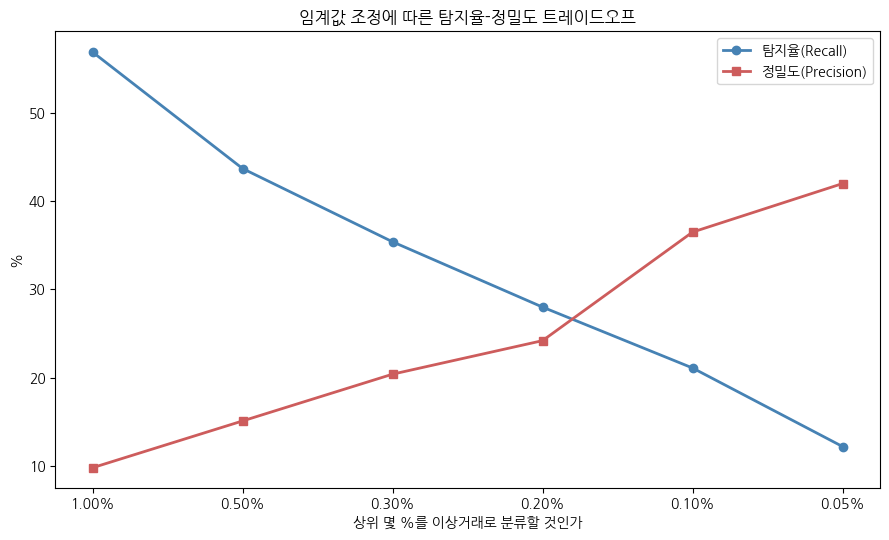

In [4]:
# ============================================================
# [Cell 4] 임계값(threshold)별 탐지율-오탐률 트레이드오프 분석
# ============================================================

# ------------------------------------------------------------
# 여러 임계값을 시도하며 recall(탐지율)과 오탐 건수를 비교
# ------------------------------------------------------------
thresholds_to_test = np.percentile(anomaly_score, [99, 99.5, 99.7, 99.8, 99.9, 99.95])

results = []
for pct, thresh in zip([99, 99.5, 99.7, 99.8, 99.9, 99.95], thresholds_to_test):
    pred = (anomaly_score >= thresh).astype(int)
    tp = ((pred == 1) & (y_true == 1)).sum()
    fp = ((pred == 1) & (y_true == 0)).sum()
    fn = ((pred == 0) & (y_true == 1)).sum()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    flagged = pred.sum()
    results.append({
        '상위 몇%를 이상거래로 분류': f'{100-pct:.2f}%',
        '탐지된 사기': tp, '실제 사기': int(y_true.sum()),
        '탐지율(Recall)': f'{recall*100:.1f}%',
        '정밀도(Precision)': f'{precision*100:.1f}%',
        '전체 이상거래 플래그 건수': flagged
    })

threshold_df = pd.DataFrame(results)
print("=== 임계값별 트레이드오프 ===")
print(threshold_df.to_string(index=False))

# ------------------------------------------------------------
# 시각화: 임계값(상위 %)에 따른 Recall vs Precision 변화
# ------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(9, 5.5))
x_labels = [r['상위 몇%를 이상거래로 분류'] for r in results]
recalls = [float(r['탐지율(Recall)'].replace('%','')) for r in results]
precisions = [float(r['정밀도(Precision)'].replace('%','')) for r in results]

ax1.plot(x_labels, recalls, marker='o', color='steelblue', label='탐지율(Recall)', lw=2)
ax1.plot(x_labels, precisions, marker='s', color='indianred', label='정밀도(Precision)', lw=2)
ax1.set_xlabel('상위 몇 %를 이상거래로 분류할 것인가')
ax1.set_ylabel('%')
ax1.set_title('임계값 조정에 따른 탐지율-정밀도 트레이드오프')
ax1.legend()
plt.tight_layout()
plt.show()

확인 포인트 : 상위 0.05%(가장 이상치 점수가 높은 극소수)만 플래그하면 정밀도는 높지만 탐지율은 낮고, 상위 1%까지 넓게 플래그하면 탐지율은 오르지만 정밀도가 떨어지는 전형적인 트레이드오프가 보여야 정상이다.
이게 실무에서 "이상거래 탐지 임계값을 어디에 둘 것인가"가 왜 리스크관리 정책 결정 사항인지(너무 낮추면 고객 불편·상담원 업무량 폭증, 너무 높이면 사기 놓침) 보여주는 핵심 근거가 된다.

완벽한 X자형 트레이드오프 곡선이 나왔다. 상위 1%를 이상거래로 분류하면 탐지율 56.9%지만 정밀도는 9.8%(오탐이 압도적으로 많음), 반대로 상위 0.05%만 보면 정밀도 42%로 올라가지만 탐지율은 12.2%로 떨어진다. 두 선이 0.2%~0.3% 부근에서 교차하는 지점이 바로 "탐지력과 오탐 비용의 균형점"이라, 실제 운영에서 임계값을 잡을 때 참고할 수 있는 구체적인 근거가 된다.